In [1]:
import os
import ast
import cv2
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import albumentations as A
from albumentations.pytorch import ToTensorV2

# !pip install timm==0.6.13 -q  # uncomment on first run
import timm

print(f"PyTorch: {torch.__version__}")
print(f"timm:    {timm.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}, devices: {torch.cuda.device_count()}")

<jemalloc>: Unsupported system page size


PyTorch: 1.12.1
timm:    0.9.16
CUDA:    True, devices: 4


In [2]:
class CFG:
    # --- paths ---
    BASE_PATH       = "/datasets/multi-view-pig-posture-recognition"
    TRAIN_CSV       = f"{BASE_PATH}/train2.csv"
    TEST_CSV        = f"{BASE_PATH}/test.csv"
    SAMPLE_SUB_CSV  = f"{BASE_PATH}/sample_submission.csv"
    CLASS_TXT       = f"{BASE_PATH}/pig_posture_classes.txt"
    TRAIN_IMG_DIR   = f"{BASE_PATH}/train2_images"
    TEST_IMG_DIR    = f"{BASE_PATH}/test_images"

    # --- model ---
    BACKBONE    = "tf_efficientnetv2_s"  # best accuracy/speed for timm 0.6.x
    IMG_SIZE    = 300
    NUM_CLASSES = 5
    DROP_RATE   = 0.3
    DROP_PATH   = 0.2

    # --- training ---
    BATCH_SIZE   = 12
    EPOCHS       = 20
    LR           = 2e-4
    WEIGHT_DECAY = 1e-4
    N_FOLDS      = 5
    PATIENCE     = 4
    SEED         = 42

    # --- dataset ---
    CONTEXT_RATIO = 0.1   # expand bbox by 10% for surrounding context
    NUM_WORKERS   = 4

    # --- device ---
    DEVICE = "cuda:2"


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.SEED)

# Verify paths
for p in [CFG.TRAIN_CSV, CFG.TEST_CSV, CFG.SAMPLE_SUB_CSV,
          CFG.CLASS_TXT, CFG.TRAIN_IMG_DIR, CFG.TEST_IMG_DIR]:
    status = "✓" if os.path.exists(p) else "✗ MISSING"
    print(f"  {status}  {p}")

  ✓  /datasets/multi-view-pig-posture-recognition/train2.csv
  ✓  /datasets/multi-view-pig-posture-recognition/test.csv
  ✓  /datasets/multi-view-pig-posture-recognition/sample_submission.csv
  ✓  /datasets/multi-view-pig-posture-recognition/pig_posture_classes.txt
  ✓  /datasets/multi-view-pig-posture-recognition/train2_images
  ✓  /datasets/multi-view-pig-posture-recognition/test_images


In [3]:
train_df = pd.read_csv(CFG.TRAIN_CSV)
test_df  = pd.read_csv(CFG.TEST_CSV)
sample_submission = pd.read_csv(CFG.SAMPLE_SUB_CSV)

with open(CFG.CLASS_TXT, "r") as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Classes: {classes}")
print(f"Train: {len(train_df)} instances, {train_df['image_id'].nunique()} images")
print(f"Test:  {len(test_df)} instances, {test_df['image_id'].nunique()} images")
train_df.head()

Classes: ['Lateral_lying_left', 'Lateral_lying_right', 'Sitting', 'Standing', 'Sternal_lying']
Train: 23450 instances, 3150 images
Test:  11708 instances, 1350 images


,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [4]:
# bbox format is [xmin, ymin, w, h] (top-left corner)
def parse_bbox(bbox_str):
    vals = ast.literal_eval(bbox_str) if isinstance(bbox_str, str) else bbox_str
    return [float(v) for v in vals]

train_df[["xmin", "ymin", "w", "h"]] = pd.DataFrame(
    train_df["bbox"].apply(parse_bbox).tolist(),
    index=train_df.index
)
train_df["area"] = train_df["w"] * train_df["h"]

# Sanity check: coords should be non-negative and within image bounds
print("Negative xmin:", (train_df["xmin"] < 0).sum())
print("Negative ymin:", (train_df["ymin"] < 0).sum())
print("xmin+w > width:", (train_df["xmin"] + train_df["w"] > train_df["width"]).sum())
print("ymin+h > height:", (train_df["ymin"] + train_df["h"] > train_df["height"]).sum())
print(train_df[["xmin", "ymin", "w", "h", "area"]].describe())

Negative xmin: 0
Negative ymin: 0
xmin+w > width: 0
ymin+h > height: 0
               xmin          ymin             w             h           area
count  23450.000000  23450.000000  23450.000000  23450.000000   23450.000000
mean     540.146316    316.109612    300.014670    295.973906   95399.564287
std      364.459182    216.150594    147.973854    141.796523   82868.543783
min        1.500000      0.000000     44.400000     75.000000    6900.320000
25%      253.500000    135.500000    187.000000    188.925000   45640.402500
50%      475.500000    307.000000    281.000000    258.150000   70118.500000
75%      725.650000    444.000000    383.000000    395.000000  110339.500000
max     2238.000000   1264.700000   1120.000000   1164.000000  763617.000000


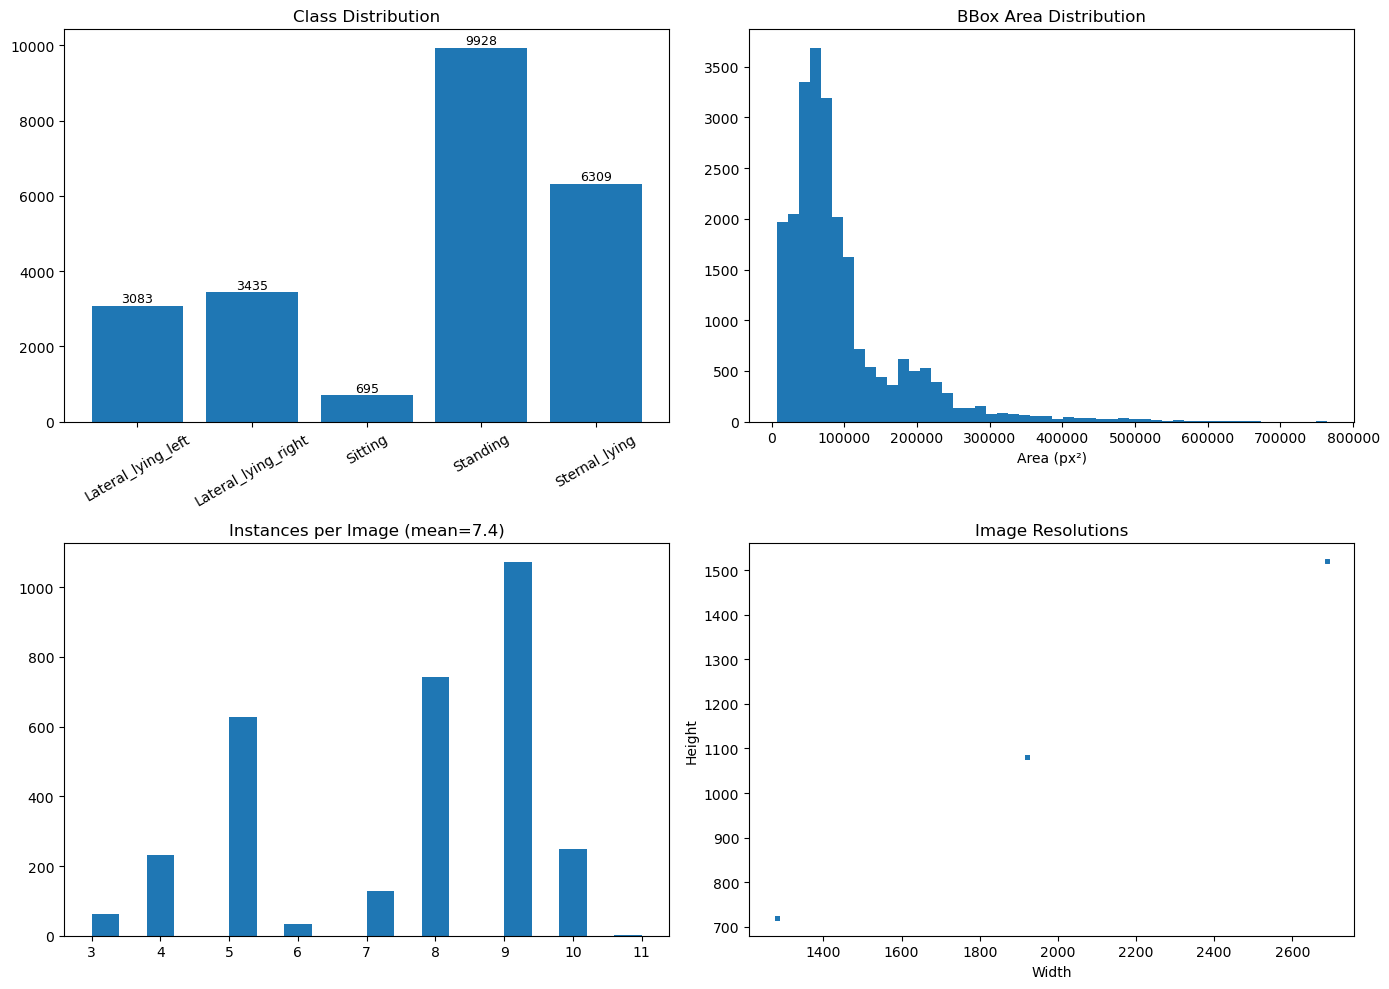


Resolution stats:
             width       height
count  3150.000000  3150.000000
mean   1611.946667   907.225397
std     413.067697   233.671967
min    1280.000000   720.000000
25%    1280.000000   720.000000
50%    1280.000000   720.000000
75%    1920.000000  1080.000000
max    2688.000000  1520.000000


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5a — Class distribution
class_counts = train_df["class_id"].value_counts().sort_index()
axes[0, 0].bar(range(len(classes)), class_counts.values, tick_label=classes)
axes[0, 0].set_title("Class Distribution")
axes[0, 0].tick_params(axis="x", rotation=30)
for i, v in enumerate(class_counts.values):
    axes[0, 0].text(i, v + 100, str(v), ha="center", fontsize=9)

# 5b — BBox area distribution
axes[0, 1].hist(train_df["area"], bins=50)
axes[0, 1].set_title("BBox Area Distribution")
axes[0, 1].set_xlabel("Area (px²)")

# 5c — Instances per image
instances_per_image = train_df.groupby("image_id").size()
axes[1, 0].hist(instances_per_image, bins=20)
axes[1, 0].set_title(f"Instances per Image (mean={instances_per_image.mean():.1f})")

# 5d — Image resolution (from CSV columns, no disk read needed)
res = train_df.groupby("image_id")[["width", "height"]].first()
axes[1, 1].scatter(res["width"], res["height"], alpha=0.3, s=5)
axes[1, 1].set_title("Image Resolutions")
axes[1, 1].set_xlabel("Width")
axes[1, 1].set_ylabel("Height")

plt.tight_layout()
plt.show()

print(f"\nResolution stats:\n{res.describe()}")

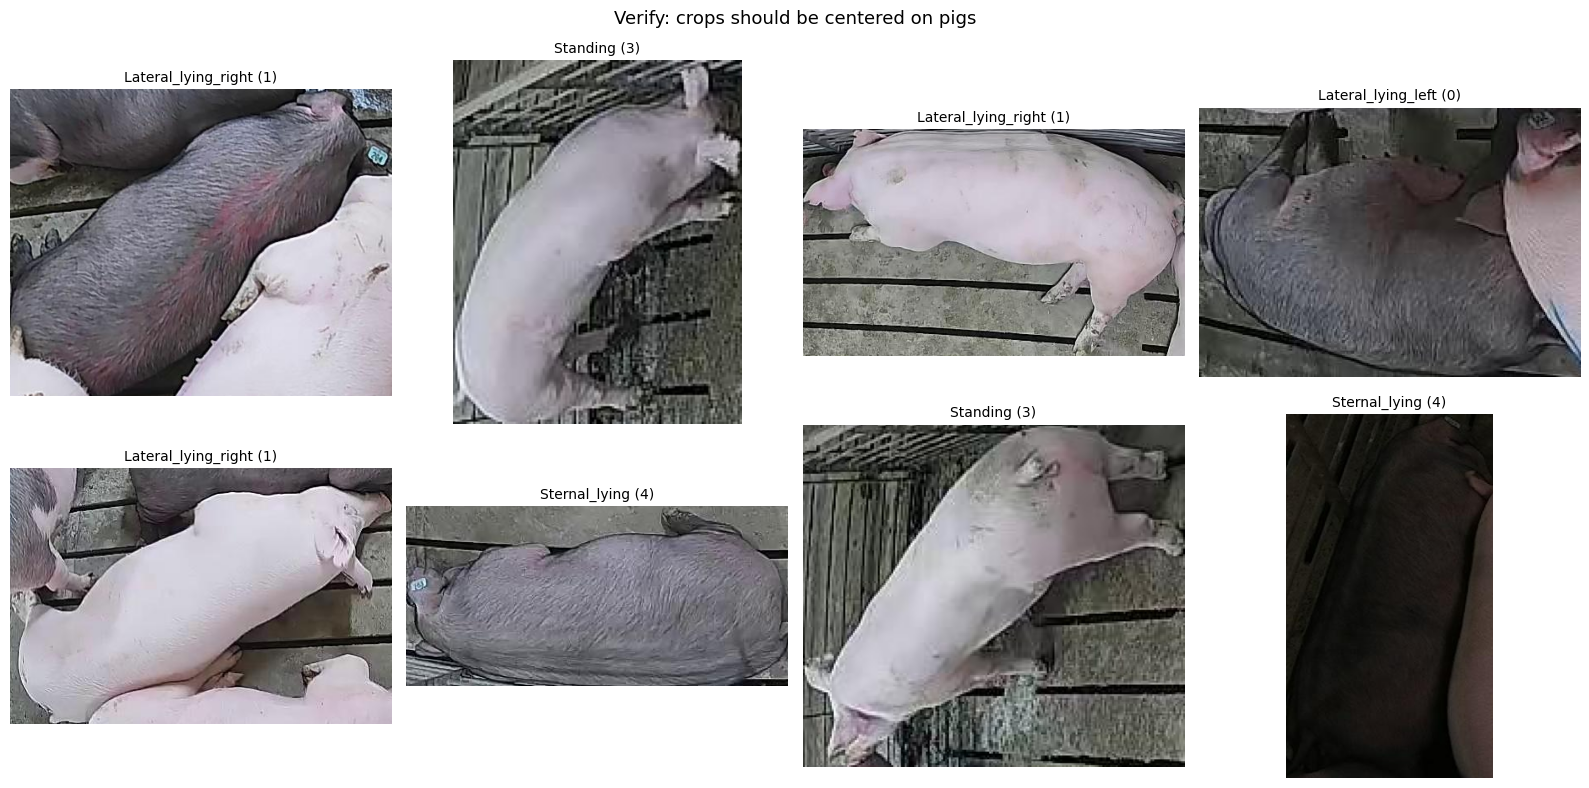

In [6]:
def show_random_samples(df, img_dir, num_samples=8):
    samples = df.sample(num_samples, random_state=CFG.SEED)
    cols = min(num_samples, 4)
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()

    for i, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(os.path.join(img_dir, row["image_id"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        xmin, ymin, w, h = row["xmin"], row["ymin"], row["w"], row["h"]
        ix1 = max(0, int(xmin))
        iy1 = max(0, int(ymin))
        ix2 = min(W, int(xmin + w))
        iy2 = min(H, int(ymin + h))
        crop = img[iy1:iy2, ix1:ix2]

        axes[i].imshow(crop)
        axes[i].set_title(f"{classes[row['class_id']]} ({row['class_id']})", fontsize=10)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.suptitle("Verify: crops should be centered on pigs", fontsize=13)
    plt.tight_layout()
    plt.show()

show_random_samples(train_df, CFG.TRAIN_IMG_DIR, num_samples=8)

In [7]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, p=0.5),
    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
    ], p=0.2),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

valid_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

/opt/conda/envs/torch/lib/python3.10/site-packages/albumentations/augmentations/blur/transforms.py:184: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


In [8]:
class PigDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False,
                 context_ratio=0.1):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        self.context_ratio = context_ratio

        # Pre-parse all bboxes as [xmin, ymin, w, h] (top-left format)
        self.bboxes = []
        for bbox_raw in self.df["bbox"].values:
            vals = ast.literal_eval(bbox_raw) if isinstance(bbox_raw, str) else bbox_raw
            self.bboxes.append([float(v) for v in vals])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        xmin, ymin, w, h = self.bboxes[idx]

        # Expand by context_ratio for surrounding context
        pad_w = w * self.context_ratio
        pad_h = h * self.context_ratio

        H_img, W_img = img.shape[:2]
        ix1 = max(0, int(xmin - pad_w))
        iy1 = max(0, int(ymin - pad_h))
        ix2 = min(W_img, int(xmin + w + pad_w))
        iy2 = min(H_img, int(ymin + h + pad_h))

        crop = img[iy1:iy2, ix1:ix2]
        if crop.size == 0:
            crop = img  # fallback

        if self.transform:
            crop = self.transform(image=crop)["image"]

        if self.is_test:
            return crop
        return crop, int(row["class_id"])

In [9]:
class PigModel(nn.Module):
    def __init__(self, backbone_name=CFG.BACKBONE, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            drop_rate=CFG.DROP_RATE,
            drop_path_rate=CFG.DROP_PATH,
        )
        num_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.BatchNorm1d(num_features),
            nn.Dropout(0.4),
            nn.Linear(num_features, 256),
            nn.SiLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, CFG.NUM_CLASSES),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

# Quick test
_m = PigModel(pretrained=False)
_out = _m(torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE))
print(f"Model output shape: {_out.shape}")  # [2, 5]
print(f"Backbone features:  {_m.backbone.num_features}")
print(f"Total params:       {sum(p.numel() for p in _m.parameters()):,}")
del _m, _out

Model output shape: torch.Size([2, 5])
Backbone features:  1280
Total params:       20,509,269


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # per-class weight tensor
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            focal_weight = focal_weight * at
        return (focal_weight * ce_loss).mean()

# Inverse-frequency class weights
class_counts = train_df["class_id"].value_counts().sort_index()
alpha = len(train_df) / (CFG.NUM_CLASSES * class_counts)
alpha = torch.tensor(alpha.values, dtype=torch.float32).to(CFG.DEVICE)
print("Class weights (alpha):", alpha)

criterion = FocalLoss(alpha=alpha, gamma=2.0)

Class weights (alpha): tensor([1.5212, 1.3654, 6.7482, 0.4724, 0.7434], device='cuda:2')


In [ ]:
skf = StratifiedGroupKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df, train_df["class_id"], groups=train_df["image_id"])
):
    print(f"\n{'='*20} FOLD {fold+1}/{CFG.N_FOLDS} {'='*20}")
    print(f"Train: {len(train_idx)}, Val: {len(val_idx)}")

    # --- Datasets & Loaders ---
    train_ds = PigDataset(train_df.iloc[train_idx], CFG.TRAIN_IMG_DIR,
                          train_transform, context_ratio=CFG.CONTEXT_RATIO)
    val_ds   = PigDataset(train_df.iloc[val_idx], CFG.TRAIN_IMG_DIR,
                          valid_transform, context_ratio=CFG.CONTEXT_RATIO)

    train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                              num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                              num_workers=CFG.NUM_WORKERS, pin_memory=True)

    # --- Model, Optimizer, Scheduler ---
    model = PigModel(pretrained=True).to(CFG.DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)
    scaler = GradScaler()

    best_f1 = 0.0
    patience_counter = 0
    save_path = f"best_model_fold{fold}.pth"

    for epoch in range(CFG.EPOCHS):
        # --- Train ---
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"F{fold+1} E{epoch+1} [Train]")
        for imgs, labels in pbar:
            imgs = imgs.to(CFG.DEVICE, non_blocking=True)
            labels = labels.to(CFG.DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits = model(imgs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()

        # --- Validate ---
        model.eval()
        val_preds, val_true = [], []

        with torch.no_grad(), autocast():
            for imgs, labels in tqdm(val_loader, desc=f"F{fold+1} E{epoch+1} [Val]"):
                imgs = imgs.to(CFG.DEVICE, non_blocking=True)
                logits = model(imgs)
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        f1 = f1_score(val_true, val_preds, average="macro")
        avg_loss = running_loss / len(train_loader)
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Val F1: {f1:.4f} | LR: {lr_now:.2e}")

        if f1 > best_f1:
            best_f1 = f1
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved {save_path} (F1={f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= CFG.PATIENCE:
                print(f"  ✗ Early stopping at epoch {epoch+1}")
                break

    print(f"  Fold {fold+1} best macro-F1: {best_f1:.4f}")
    fold_results.append({"fold": fold, "best_f1": best_f1, "path": save_path})

    # Cleanup
    del model, optimizer, scheduler, scaler, train_ds, val_ds
    torch.cuda.empty_cache()

# Summary
print("\n" + "=" * 50)
for r in fold_results:
    print(f"  Fold {r['fold']+1}: F1 = {r['best_f1']:.4f}")
mean_f1 = np.mean([r["best_f1"] for r in fold_results])
print(f"  Mean CV F1: {mean_f1:.4f}")


==================== FOLD 1/5 ====================
Train: 18766, Val: 4684


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

F1 E1 [Val]: 100%|██████████| 196/196 [00:32<00:00,  6.03it/s]


  Epoch  1 | Loss: 0.5684 | Val F1: 0.7109 | LR: 1.99e-04
  ✓ Saved best_model_fold0.pth (F1=0.7109)


...

F1 E18 [Val]: 100%|██████████| 196/196 [00:28<00:00,  6.99it/s]


  Epoch 18 | Loss: 0.0433 | Val F1: 0.9357 | LR: 5.87e-06
  ✓ Saved best_model_fold0.pth (F1=0.9357)


F1 E19 [Val]: 100%|██████████| 196/196 [00:30<00:00,  6.51it/s]


  Epoch 19 | Loss: 0.0280 | Val F1: 0.9399 | LR: 2.23e-06
  ✓ Saved best_model_fold0.pth (F1=0.9399)


F1 E20 [Train]:  13%|█▎        | 199/1563 [01:00<06:45,  3.37it/s, loss=0.0099]

In [ ]:
# --- Collect saved models ---
fold_models = sorted(glob.glob("best_model_fold*.pth"))
print(f"Found {len(fold_models)} fold models: {fold_models}")
assert len(fold_models) > 0, "No saved models found!"

# --- Test dataset ---
test_dataset = PigDataset(test_df, CFG.TEST_IMG_DIR, valid_transform,
                          is_test=True, context_ratio=CFG.CONTEXT_RATIO)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                         num_workers=CFG.NUM_WORKERS, pin_memory=True)

# --- Inference ---
all_fold_probs = []

for fold_path in fold_models:
    print(f"Inferring: {fold_path}")
    model = PigModel(pretrained=False).to(CFG.DEVICE)
    model.load_state_dict(torch.load(fold_path, map_location=CFG.DEVICE))
    model.eval()

    fold_probs = []
    with torch.no_grad(), autocast():
        for imgs in tqdm(test_loader):
            imgs = imgs.to(CFG.DEVICE, non_blocking=True)
            # TTA: original + hflip + vflip
            p1 = torch.softmax(model(imgs), dim=1)
            p2 = torch.softmax(model(torch.flip(imgs, dims=[3])), dim=1)
            p3 = torch.softmax(model(torch.flip(imgs, dims=[2])), dim=1)
            fold_probs.append(((p1 + p2 + p3) / 3.0).cpu().numpy())

    all_fold_probs.append(np.concatenate(fold_probs, axis=0))

    del model
    torch.cuda.empty_cache()

# --- Ensemble (mean probabilities across folds) ---
final_probs = np.mean(all_fold_probs, axis=0)
final_preds = np.argmax(final_probs, axis=1)

print("\nPrediction distribution:")
for cid, name in enumerate(classes):
    count = (final_preds == cid).sum()
    print(f"  {cid} ({name}): {count}")

# --- Save submission ---
submission = pd.DataFrame({
    "row_id": test_df["row_id"],
    "class_id": final_preds
})
submission.to_csv("submission2.csv", index=False)
print(f"\n✓ Submission saved: {len(submission)} rows")
submission.head(10)